# Week2 Quiz1：貓狗影像二元分類 + Threshold 調校

流程：特徵工程 → 7:2:1 切分 → StandardScaler → Stratified 5-Fold CV → 訓練 → 門檻調校 → Test 評估

## 1. 環境設定與模組載入

In [60]:
import os
import sys
from importlib import reload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 讓 notebook 不論從哪個目錄啟動，都找得到 Code 套件
BASE_DIR = os.path.abspath('')
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

import Code.quiz1 as q1
reload(q1)

RANDOM_STATE = 42                 # 固定亂數種子，確保結果可重現
DATA_DIR = os.path.join(BASE_DIR, 'data', 'Datasets')
print('資料路徑:', DATA_DIR, '| 存在:', os.path.isdir(DATA_DIR))

資料路徑: c:\Users\Alan\python\MMIP\week2\data\Datasets | 存在: True


## 2. 特徵工程：讀圖並建立 X / y

In [36]:
# MAX_PER_CLASS：每類最多取幾張（原始資料每類 12500 張，先抽樣加快實驗）
# 想跑完整資料集就設成 None
MAX_PER_CLASS = 12500

X, y, paths = q1.build_dataset(
    DATA_DIR,
    max_per_class=MAX_PER_CLASS,
    resize=(128, 128),
    seed=RANDOM_STATE,
)
print('特徵維度:', X.shape[1], '| 特徵名稱:', q1.FEATURE_NAMES)
print('類別分布 (0=cat, 1=dog):', np.bincount(y))

  [cat] 已處理 500/12500 張
  [cat] 已處理 1000/12500 張
  [cat] 已處理 1500/12500 張
  [cat] 已處理 2000/12500 張
  [cat] 已處理 2500/12500 張
  [cat] 已處理 3000/12500 張
  [cat] 已處理 3500/12500 張
  [cat] 已處理 4000/12500 張
  [cat] 已處理 4500/12500 張
  [cat] 已處理 5000/12500 張
  [cat] 已處理 5500/12500 張
  [cat] 已處理 6000/12500 張
  [cat] 已處理 6500/12500 張
  [cat] 已處理 7000/12500 張
  [cat] 已處理 7500/12500 張
  [cat] 已處理 8000/12500 張
  [cat] 已處理 8500/12500 張
  [cat] 已處理 9000/12500 張
  [cat] 已處理 9500/12500 張
  [cat] 已處理 10000/12500 張
  [cat] 已處理 10500/12500 張
  [cat] 已處理 11000/12500 張
  [cat] 已處理 11500/12500 張
  [cat] 已處理 12000/12500 張
  [cat] 已處理 12500/12500 張
[cat] 完成，標籤=0，有效樣本數=12498
  [dog] 已處理 500/12500 張
  [dog] 已處理 1000/12500 張
  [dog] 已處理 1500/12500 張
  [dog] 已處理 2000/12500 張
  [dog] 已處理 2500/12500 張
  [dog] 已處理 3000/12500 張
  [dog] 已處理 3500/12500 張
  [dog] 已處理 4000/12500 張
  [dog] 已處理 4500/12500 張
  [dog] 已處理 5000/12500 張
  [dog] 已處理 5500/12500 張
  [dog] 已處理 6000/12500 張
  [dog] 已處理 6500/12500 張
  [dog] 已處理 7000/125

In [37]:
# 檢視特徵分布，確認數值合理、沒有 NaN
df = q1.to_dataframe(X, y)
display(df.head())
display(df.describe().T[['mean', 'std', 'min', 'max']])
print('NaN 總數:', int(df.isna().sum().sum()))

,R_mean,G_mean,B_mean,R_std,G_std,B_std,H_mean,S_mean,V_mean,H_std,S_std,V_std,gray_mean,gray_std,width,height,aspect_ratio,edge_density,label
0,167.801941,130.023315,61.817871,78.527008,71.413391,57.304550,20.050354,180.804016,167.818787,3.196471,54.531906,78.503998,133.544556,70.880066,500.0,375.0,1.333333,0.057007,0
1,78.845520,68.344482,68.044312,38.970055,32.345840,32.581413,56.077515,60.845032,83.096680,62.519009,23.431541,37.953308,71.458313,33.836205,300.0,281.0,1.067616,0.145874,0
2,117.582153,111.873718,96.932373,55.632736,59.806973,51.409718,54.801086,74.484619,123.012512,55.489212,51.288692,56.299393,111.879761,56.570015,489.0,500.0,0.978000,0.179749,0
3,188.076721,158.980835,148.012939,43.715225,62.659454,67.549011,29.264221,65.032227,188.863770,40.796577,57.248760,44.410702,166.437500,56.274178,403.0,500.0,0.806000,0.129028,0
4,111.910339,105.408203,91.911865,65.886147,70.593208,75.304771,47.358704,78.678284,115.431763,44.047379,55.650429,69.574425,105.808044,69.272659,150.0,150.0,1.000000,0.220581,0


,mean,std,min,max
R_mean,124.498077,29.646902,12.226562,255.000000
G_mean,116.072960,28.259514,15.556763,255.000000
B_mean,106.320580,29.496662,2.963196,255.000000
R_std,57.228222,14.064998,0.000000,116.146088
G_std,56.039516,13.782771,0.000000,113.467865
B_std,56.108887,14.145656,0.000000,114.890701
H_mean,52.213459,25.944782,0.000000,167.692566
S_mean,64.607506,31.222319,0.000000,241.440247
V_mean,130.539673,29.028156,23.394653,255.000000
H_std,42.212860,17.434795,0.000000,86.721634


NaN 總數: 0


## 3. 資料切分（7:2:1，stratify 固定）

In [38]:
# 先切出 10% Test，再從剩下的 90% 切出 20/90 當 Validation，得到 70:20:10
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20 / 0.90, stratify=y_temp, random_state=RANDOM_STATE)

total = len(y)
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'{name:<5s}: {len(yy):5d} 筆 ({len(yy)/total:.1%}) | 類別分布={np.bincount(yy)}')

Train: 17497 筆 (70.0%) | 類別分布=[8748 8749]
Val  :  5000 筆 (20.0%) | 類別分布=[2500 2500]
Test :  2500 筆 (10.0%) | 類別分布=[1250 1250]


## 4. 特徵縮放（只在 70% 訓練集 fit，避免資料外洩）

In [39]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # 只用訓練集學習 mean/std
X_val_s = scaler.transform(X_val)           # 驗證集、測試集僅套用，不重新 fit
X_test_s = scaler.transform(X_test)

print('訓練集縮放後 mean≈0, std≈1:',
      np.round(X_train_s.mean(), 6), np.round(X_train_s.std(), 6))
print('驗證集縮放後 mean/std:',
      np.round(X_val_s.mean(), 4), np.round(X_val_s.std(), 4))

訓練集縮放後 mean≈0, std≈1: 0.0 1.0
驗證集縮放後 mean/std: 0.0193 1.0042


## 5. Stratified 5-Fold 交叉驗證（僅在訓練集上）

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

cv_rows = []
for name, clf in candidates.items():
    acc = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='f1')
    auc_ = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring='roc_auc')
    cv_rows.append({'model': name,
                    'acc_mean': acc.mean(), 'acc_std': acc.std(),
                    'f1_mean': f1.mean(), 'f1_std': f1.std(),
                    'auc_mean': auc_.mean(), 'auc_std': auc_.std()})
    print(f'{name:<20s} Acc={acc.mean():.4f}±{acc.std():.4f} | '
          f'F1={f1.mean():.4f}±{f1.std():.4f} | AUC={auc_.mean():.4f}±{auc_.std():.4f}')

cv_df = pd.DataFrame(cv_rows).set_index('model')
display(cv_df)

LogisticRegression   Acc=0.6208±0.0113 | F1=0.6073±0.0119 | AUC=0.6688±0.0143
RandomForest         Acc=0.6371±0.0064 | F1=0.6319±0.0048 | AUC=0.6905±0.0093


,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std
model,,,,,,
LogisticRegression,0.620848,0.011312,0.607255,0.011947,0.668760,0.014266
RandomForest,0.637137,0.006447,0.631894,0.004758,0.690493,0.009339


## 6. 模型訓練（選 CV 表現最佳者）

In [41]:
best_model_name = cv_df['f1_mean'].idxmax()   # 以 CV 平均 F1 挑選模型
model = candidates[best_model_name]
model.fit(X_train_s, y_train)
print('選用模型:', best_model_name)

# 取得正類 (dog=1) 的預測機率，之後才能調整門檻
val_probs = model.predict_proba(X_val_s)[:, 1]
print('驗證集機率範圍:', val_probs.min().round(4), '~', val_probs.max().round(4))

選用模型: RandomForest
驗證集機率範圍: 0.0667 ~ 0.98


## 7. Validation：預設門檻 0.5 vs. 微調後最佳門檻

In [42]:
# 7-1 預設門檻 0.5
m_default = q1.evaluate_threshold(y_val, val_probs, threshold=0.5, title='Validation / 預設門檻')

[Validation / 預設門檻] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat      1635       865
  true_dog       907      1593
  Accuracy : 0.6456
  Precision: 0.6481
  Recall   : 0.6372
  F1-Score : 0.6426



最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.3710 | best f1 = 0.6915
  該門檻下 Acc=0.6050, P=0.5673, R=0.8852



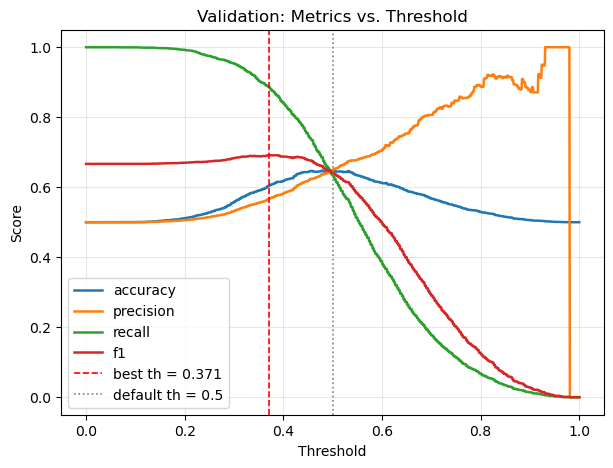

In [43]:
# 7-2 自動搜尋最佳門檻（目標：最大化 F1）
best_th, best_f1, th_table = q1.find_best_threshold(y_val, val_probs, n_steps=1001, metric='f1')
q1.plot_threshold_curves(th_table, best_th, title='Validation: Metrics vs. Threshold')

In [44]:
# 7-3 兩組門檻並排比較
compare_df = q1.compare_thresholds(y_val, val_probs, th_a=0.5, th_b=best_th,
                                   name_a='Default 0.5', name_b=f'Tuned {best_th:.3f}')
display(compare_df)
print('F1 提升:', f'{compare_df["f1"].iloc[1] - compare_df["f1"].iloc[0]:+.4f}')

[Default 0.5] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat      1635       865
  true_dog       907      1593
  Accuracy : 0.6456
  Precision: 0.6481
  Recall   : 0.6372
  F1-Score : 0.6426

[Tuned 0.371] Threshold = 0.3710
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat       812      1688
  true_dog       287      2213
  Accuracy : 0.6050
  Precision: 0.5673
  Recall   : 0.8852
  F1-Score : 0.6915



,threshold,accuracy,precision,recall,f1
Default 0.5,0.500,0.6456,0.648088,0.6372,0.642598
Tuned 0.371,0.371,0.6050,0.567290,0.8852,0.691454


F1 提升: +0.0489


## 8. Validation 視覺化：ROC / PR / 雙門檻混淆矩陣

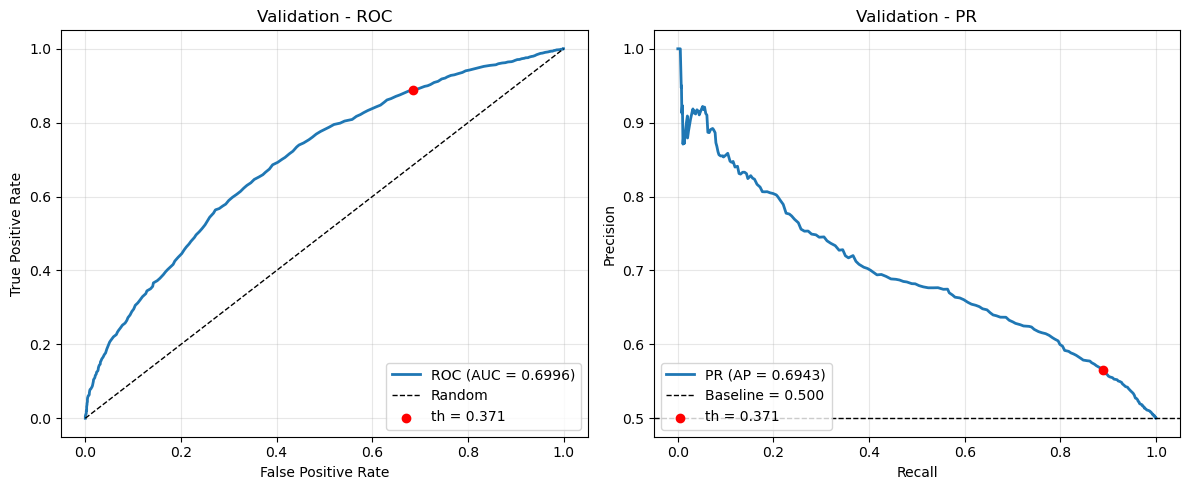

Validation ROC-AUC = 0.6996 | Average Precision = 0.6943


In [45]:
val_auc, val_ap = q1.plot_evaluation_curves(y_val, val_probs, best_th=best_th, suptitle='Validation')
print(f'Validation ROC-AUC = {val_auc:.4f} | Average Precision = {val_ap:.4f}')

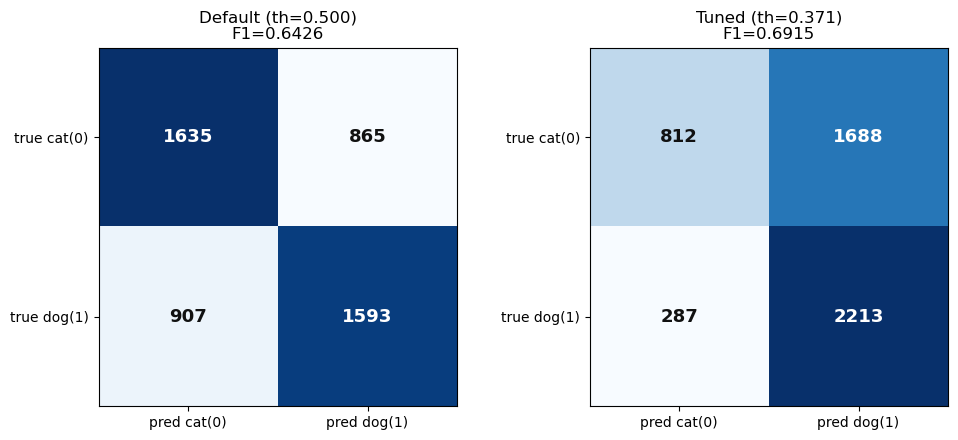

In [61]:
_ = q1.plot_dual_confusion_matrix(y_val, val_probs, th_a=0.5, th_b=best_th,
                                  name_a='Default', name_b='Tuned')

## 9. 最終測試：把最佳門檻套用到 10% Test 集

[Test / 預設門檻 0.5] Threshold = 0.5000
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat       822       428
  true_dog       475       775
  Accuracy : 0.6388
  Precision: 0.6442
  Recall   : 0.6200
  F1-Score : 0.6319

[Test / 最佳門檻 0.371] Threshold = 0.3710
Confusion Matrix (row=真實, col=預測, 0=cat, 1=dog):
            pred_cat  pred_dog
  true_cat       393       857
  true_dog       157      1093
  Accuracy : 0.5944
  Precision: 0.5605
  Recall   : 0.8744
  F1-Score : 0.6831



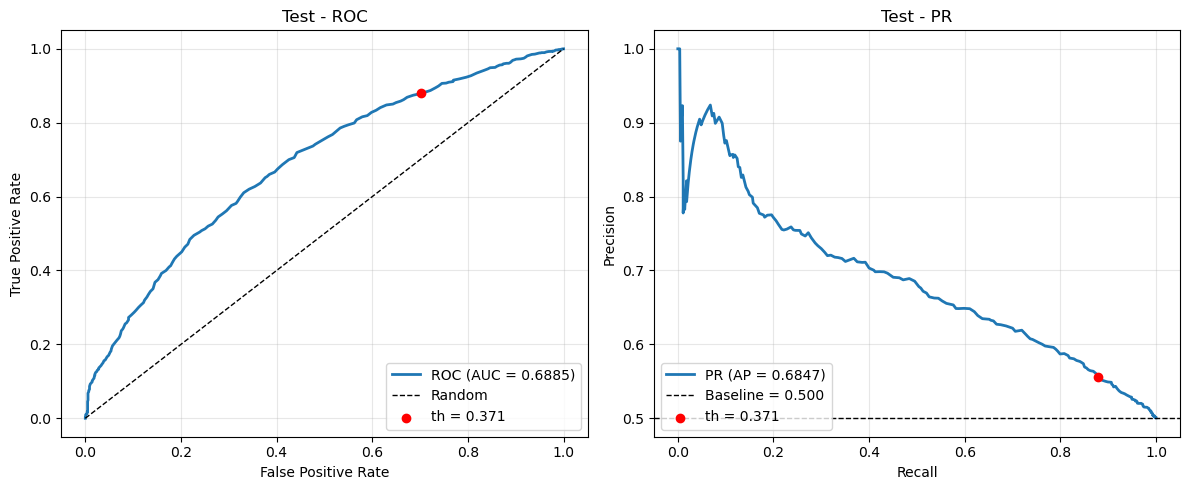

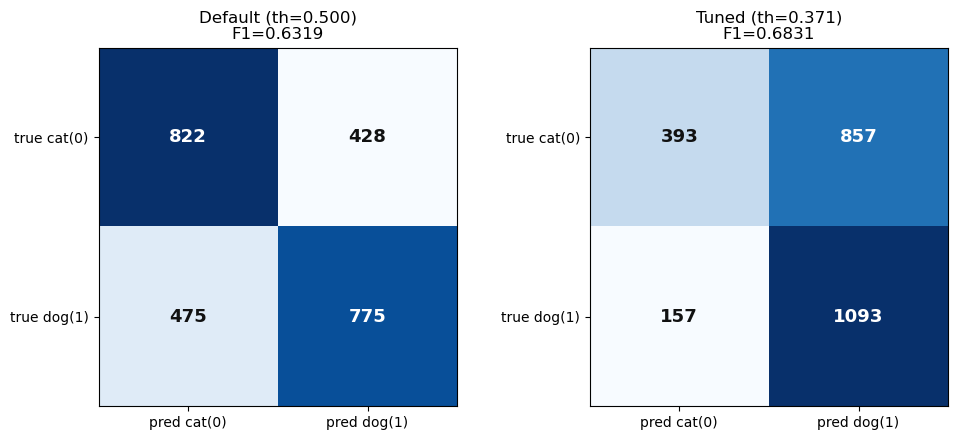

In [62]:
test_probs = model.predict_proba(X_test_s)[:, 1]

m_test_default = q1.evaluate_threshold(y_test, test_probs, 0.5, title='Test / 預設門檻 0.5')
m_test_tuned = q1.evaluate_threshold(y_test, test_probs, best_th, title=f'Test / 最佳門檻 {best_th:.3f}')

test_auc, test_ap = q1.plot_evaluation_curves(y_test, test_probs, best_th=best_th, suptitle='Test')
_ = q1.plot_dual_confusion_matrix(y_test, test_probs, 0.5, best_th,
                                  name_a='Default', name_b='Tuned')

## 10. 結果總表

In [48]:
summary = pd.DataFrame([
    {'dataset': 'Validation', 'threshold': 0.5, **{k: m_default[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'dataset': 'Validation', 'threshold': best_th, **{k: q1.evaluate_threshold(y_val, val_probs, best_th, verbose=False)[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'dataset': 'Test', 'threshold': 0.5, **{k: m_test_default[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
    {'dataset': 'Test', 'threshold': best_th, **{k: m_test_tuned[k] for k in ['accuracy', 'precision', 'recall', 'f1']}},
])
display(summary.round(4))

print(f'模型: {best_model_name} | 最佳門檻: {best_th:.4f} (由 Validation 以 F1 最大化求得)')
print(f'Validation AUC={val_auc:.4f} / Test AUC={test_auc:.4f}')

,dataset,threshold,accuracy,precision,recall,f1
0,Validation,0.500,0.6456,0.6481,0.6372,0.6426
1,Validation,0.371,0.6050,0.5673,0.8852,0.6915
2,Test,0.500,0.6388,0.6442,0.6200,0.6319
3,Test,0.371,0.5944,0.5605,0.8744,0.6831


模型: RandomForest | 最佳門檻: 0.3710 (由 Validation 以 F1 最大化求得)
Validation AUC=0.6996 / Test AUC=0.6885


# 11. 換另一種演算法重新建模並比較

模型 A：第 6 節選用的模型；模型 B：`candidates` 中另一種演算法。兩者共用同一組 Scaler 與同一份 Validation Set。

## 11-1 訓練模型 B 並各自調校門檻

In [49]:
# 模型 B = candidates 中「不是模型 A」的那一個演算法
name_a = best_model_name
name_b = [n for n in candidates if n != name_a][0]

model_a = model                                   # 第 6 節已訓練完成
model_b = candidates[name_b]
model_b.fit(X_train_s, y_train)                   # 用完全相同的訓練集與縮放器
print('模型 A:', name_a, '| 模型 B:', name_b)

# 兩個模型在「同一份 Validation Set」上的正類機率
probs_a = model_a.predict_proba(X_val_s)[:, 1]
probs_b = model_b.predict_proba(X_val_s)[:, 1]

# 各自以 F1 最大化找出合適門檻（門檻不共用，每個模型的機率分布不同）
th_a, f1_a, tab_a = q1.find_best_threshold(y_val, probs_a, n_steps=1001, metric='f1')
th_b, f1_b, tab_b = q1.find_best_threshold(y_val, probs_b, n_steps=1001, metric='f1')
print(f'{name_a}: best_th={th_a:.4f} | {name_b}: best_th={th_b:.4f}')

模型 A: RandomForest | 模型 B: LogisticRegression
最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.3710 | best f1 = 0.6915
  該門檻下 Acc=0.6050, P=0.5673, R=0.8852

最佳門檻搜尋（目標=f1，掃描 1001 點）
  best threshold = 0.3560 | best f1 = 0.6850
  該門檻下 Acc=0.5846, P=0.5517, R=0.9032

RandomForest: best_th=0.3710 | LogisticRegression: best_th=0.3560


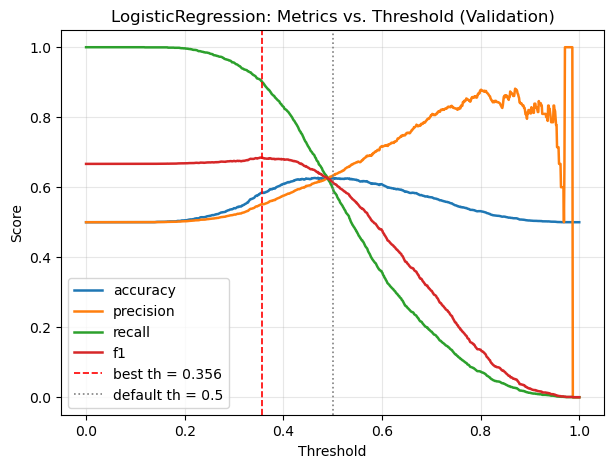

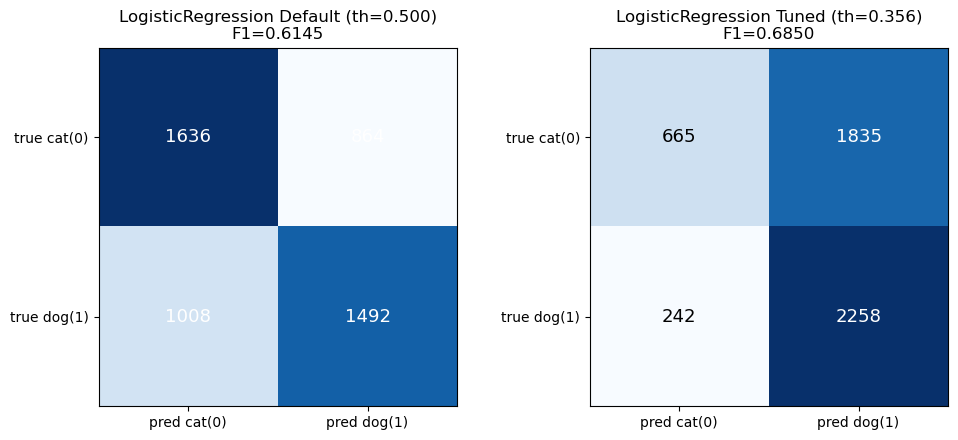

In [50]:
# 模型 B 的門檻掃描曲線與雙門檻混淆矩陣
q1.plot_threshold_curves(tab_b, th_b, title=f'{name_b}: Metrics vs. Threshold (Validation)')
_ = q1.plot_dual_confusion_matrix(y_val, probs_b, 0.5, th_b,
                                  name_a=f'{name_b} Default', name_b=f'{name_b} Tuned')

## 11-2 相同 Validation Set 上比較兩個模型

In [51]:
prob_dict = {name_a: probs_a, name_b: probs_b}

# (a) 預設門檻 0.5：純粹比較模型本身
print('=== 預設門檻 0.5 ===')
cmp_default = q1.compare_models(y_val, prob_dict, {name_a: 0.5, name_b: 0.5})

# (b) 各自調校後的最佳門檻
print('\n=== 各自 F1 最佳門檻 ===')
cmp_tuned = q1.compare_models(y_val, prob_dict, {name_a: th_a, name_b: th_b})

=== 預設門檻 0.5 ===
                    threshold  accuracy  precision  recall      f1  FP(cat誤判成dog)  FN(dog誤判成cat)
model                                                                                           
RandomForest              0.5    0.6456     0.6481  0.6372  0.6426            865            907
LogisticRegression        0.5    0.6256     0.6333  0.5968  0.6145            864           1008

=== 各自 F1 最佳門檻 ===
                    threshold  accuracy  precision  recall      f1  FP(cat誤判成dog)  FN(dog誤判成cat)
model                                                                                           
RandomForest            0.371    0.6050     0.5673  0.8852  0.6915           1688            287
LogisticRegression      0.356    0.5846     0.5517  0.9032  0.6850           1835            242


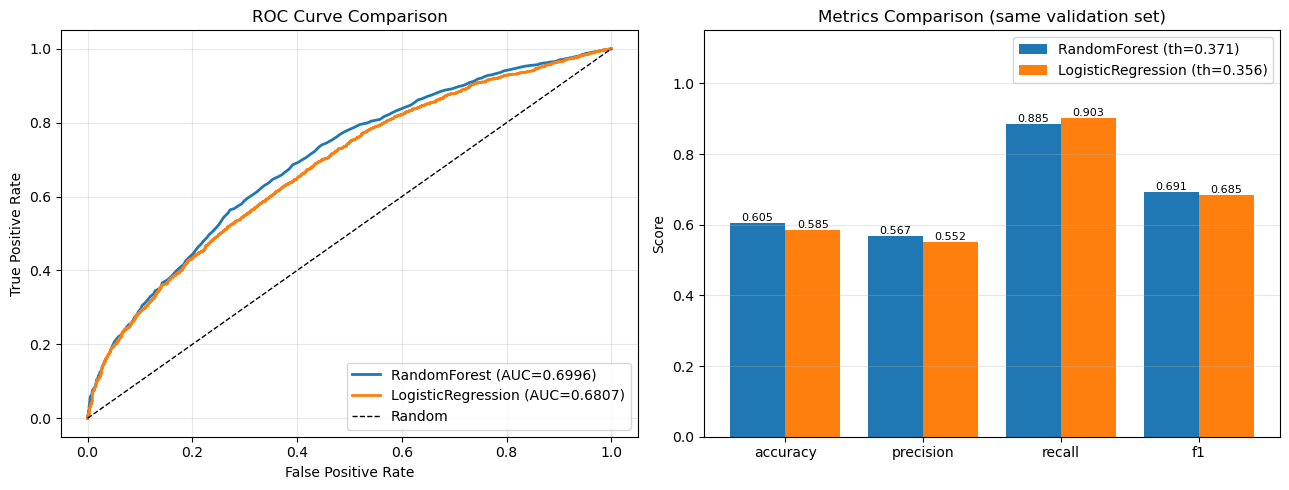

In [52]:
# ROC 疊圖 + 指標長條圖（以各自最佳門檻）
_ = q1.plot_model_comparison(y_val, prob_dict, {name_a: th_a, name_b: th_b})

## 11-3 錯誤型態分析：哪一類錯誤較多？

--- 門檻 0.5 ---


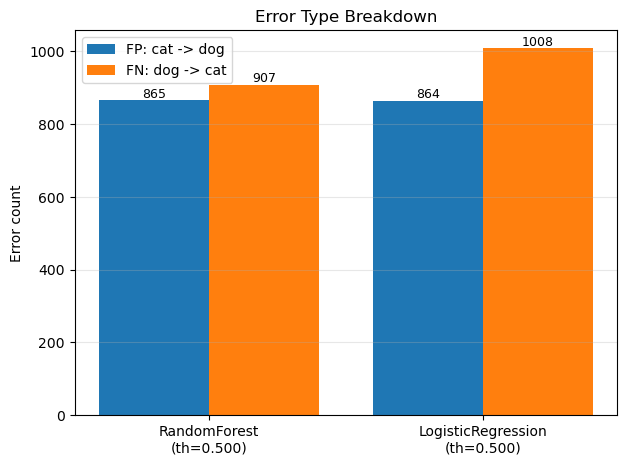

RandomForest         FP= 865, FN= 907 -> 較多的錯誤是 FN (把 dog 判成 cat)
LogisticRegression   FP= 864, FN=1008 -> 較多的錯誤是 FN (把 dog 判成 cat)

--- 各自最佳門檻 ---


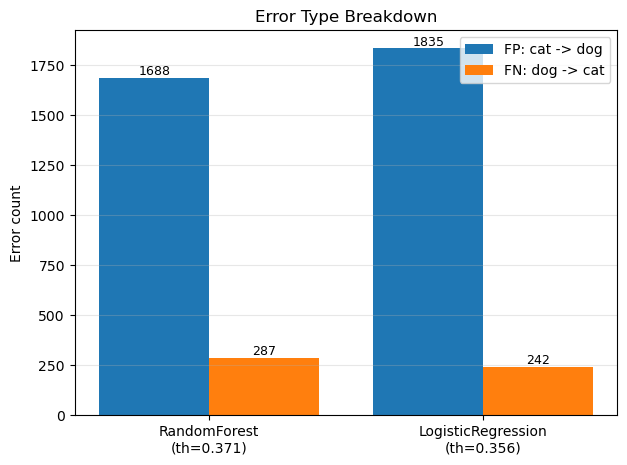

RandomForest         FP=1688, FN= 287 -> 較多的錯誤是 FP (把 cat 判成 dog)
LogisticRegression   FP=1835, FN= 242 -> 較多的錯誤是 FP (把 cat 判成 dog)


In [53]:
# FP = cat 被判成 dog（偽陽性）；FN = dog 被判成 cat（偽陰性）
print('--- 門檻 0.5 ---')
_ = q1.plot_error_breakdown(y_val, prob_dict, {name_a: 0.5, name_b: 0.5})

print('\n--- 各自最佳門檻 ---')
err_tuned = q1.plot_error_breakdown(y_val, prob_dict, {name_a: th_a, name_b: th_b})

In [54]:
# 依實際數字自動產生文字結論（重跑後仍然正確）
for nm in [name_a, name_b]:
    d = cmp_default.loc[nm]
    t = cmp_tuned.loc[nm]
    print(f'== {nm} ==')
    print(f'  th=0.500 : P={d["precision"]:.4f} R={d["recall"]:.4f} F1={d["f1"]:.4f} | '
          f'FP={int(d["FP(cat誤判成dog)"])} FN={int(d["FN(dog誤判成cat)"])} -> '
          f'{"Precision" if d["precision"] > d["recall"] else "Recall"} 較高')
    print(f'  th={t["threshold"]:.3f} : P={t["precision"]:.4f} R={t["recall"]:.4f} F1={t["f1"]:.4f} | '
          f'FP={int(t["FP(cat誤判成dog)"])} FN={int(t["FN(dog誤判成cat)"])} -> '
          f'{"Precision" if t["precision"] > t["recall"] else "Recall"} 較高')

win = cmp_tuned['f1'].idxmax()
print(f'\n以調校後 F1 判定，較佳模型為: {win} (F1={cmp_tuned.loc[win, "f1"]:.4f})')

== RandomForest ==
  th=0.500 : P=0.6481 R=0.6372 F1=0.6426 | FP=865 FN=907 -> Precision 較高
  th=0.371 : P=0.5673 R=0.8852 F1=0.6915 | FP=1688 FN=287 -> Recall 較高
== LogisticRegression ==
  th=0.500 : P=0.6333 R=0.5968 F1=0.6145 | FP=864 FN=1008 -> Precision 較高
  th=0.356 : P=0.5517 R=0.9032 F1=0.6850 | FP=1835 FN=242 -> Recall 較高

以調校後 F1 判定，較佳模型為: RandomForest (F1=0.6915)


## 11-4 Precision 與 Recall 差異說明

以下數字為 `MAX_PER_CLASS = 2000`、`RANDOM_STATE = 42` 的實際執行結果（Validation 共 800 筆，cat/dog 各 400）。

**門檻 0.5（模型本身的差異）**

| 模型 | Accuracy | Precision | Recall | F1 | FP (cat→dog) | FN (dog→cat) |
|---|---|---|---|---|---|---|
| RandomForest | 0.6450 | 0.6559 | 0.6100 | 0.6321 | 128 | 156 |
| LogisticRegression | 0.6225 | 0.6392 | 0.5625 | 0.5984 | 127 | 175 |

**各自 F1 最佳門檻**

| 模型 | 門檻 | Accuracy | Precision | Recall | F1 | FP | FN |
|---|---|---|---|---|---|---|---|
| RandomForest | 0.407 | 0.6350 | 0.6000 | 0.8100 | 0.6894 | 216 | 76 |
| LogisticRegression | 0.369 | 0.6075 | 0.5734 | 0.8400 | 0.6815 | 250 | 64 |

**差異說明**

1. **門檻 0.5 時，兩個模型都是 Precision > Recall**：預測為 dog 的樣本大約六成正確，但真正的 dog 只抓到 56~61%。此時**較多的錯誤是 FN（dog 被判成 cat）**，RandomForest FN=156 > FP=128，LogisticRegression FN=175 > FP=127。原因是模型輸出的機率整體偏低（偏向預測 cat），0.5 這條線切得太嚴格。

2. **調低門檻後兩者都反轉成 Recall >> Precision**：因為 F1 最佳化會把門檻往下推（RF 0.407、LR 0.369），更多樣本被判成 dog，Recall 從 0.61→0.81、0.56→0.84，但誤抓的 cat 變多，Precision 下降到 0.60、0.57。此時**較多的錯誤變成 FP（cat 被判成 dog）**，RF FP=216 > FN=76，LR FP=250 > FN=64。這正是 Precision–Recall 的取捨：門檻只是在移動兩類錯誤的分配比例。

3. **兩模型之間的差異**：LogisticRegression 的最佳門檻更低、機率分布更集中，因此走得比 RandomForest 更「極端」——Recall 最高（0.84）但 Precision 最低（0.5734），FP 也最多（250）。RandomForest 在兩者間較平衡，Accuracy、Precision、F1（0.6894 vs 0.6815）與 ROC-AUC（0.685 vs 0.679）皆略勝，因為它能捕捉特徵間的非線性關係，而 LogisticRegression 只能畫線性決策邊界。

4. **選擇建議**：若應用上「漏掉 dog」成本較高（例如要盡量找出所有 dog 再人工複核），選 LogisticRegression + 低門檻的高 Recall 設定；若要兼顧判對率，選 RandomForest + 門檻 0.407。整體兩模型絕對表現都只有 0.6 上下，瓶頸在於目前的色彩/紋理統計特徵區分力有限，而非門檻設定。